In [1]:
# !pip install -q datasets transformers accelerate


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [5]:
from sklearn.preprocessing import LabelEncoder


In [6]:
!pip install -q datasets


In [7]:
import re


# Preprocessing

In [8]:
from datasets import load_dataset

DATA_FILES = {
    "train": "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv",
    "test": "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv",
}

dataset = load_dataset("csv", data_files=DATA_FILES)

df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])
df = pd.concat([df_train, df_test], ignore_index=True)

df["instruction"] = df["text"].astype(str).str.strip()
df["intent"] = df["category"].astype(str).str.strip()

df = df[["instruction", "intent"]].copy()
df = df.dropna(subset=["instruction", "intent"])
df = df[(df["instruction"] != "") & (df["intent"] != "")]
df = df.drop_duplicates(subset="instruction").reset_index(drop=True)

df.head()


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

,instruction,intent
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [9]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [10]:
print(df.shape)
print(df["intent"].nunique())
df["intent"].value_counts().head(20)


(13072, 2)
77


,count
intent,
card_payment_fee_charged,227
direct_debit_payment_not_recognised,222
balance_not_updated_after_cheque_or_cash_deposit,221
wrong_amount_of_cash_received,220
cash_withdrawal_charge,217
transaction_charged_twice,215
declined_cash_withdrawal,213
transfer_fee_charged,212
balance_not_updated_after_bank_transfer,211


In [11]:
X = df["instruction"]
y = df["intent"]

encoder_intent = LabelEncoder()
y_intent = encoder_intent.fit_transform(df["intent"])

num_intent_classes = len(encoder_intent.classes_)
num_intent_classes


77

In [12]:
X.head()


,instruction
0,I am still waiting on my card?
1,What can I do if my card still hasn't arrived ...
2,I have been waiting over a week. Is the card s...
3,Can I track my card while it is in the process...
4,"How do I know if I will get my card, or if it ..."


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_intent,
    test_size=0.2,
    random_state=42,
    stratify=y_intent,
)


In [14]:
X_train.iloc[0]


'Is my new card activated?'

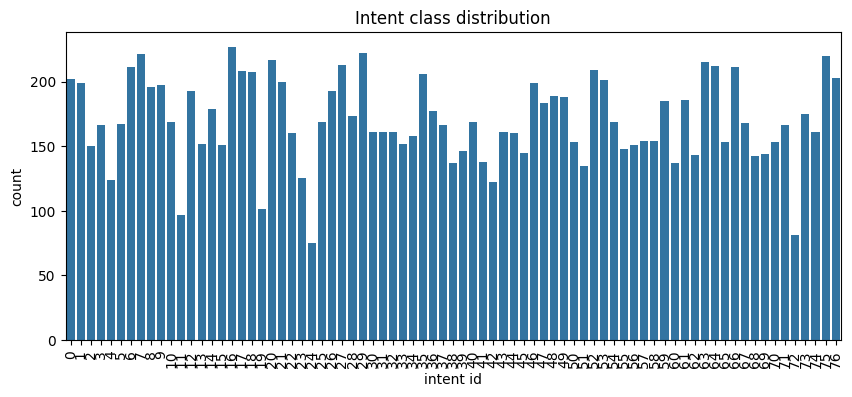

In [15]:
plt.figure(figsize=(10, 4))
sns.countplot(x=y_intent)
plt.title("Intent class distribution")
plt.xlabel("intent id")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.show()


# Baseline (logreg+tf-idf)

In [16]:
X_train_tfidf = X_train.astype(str).apply(preprocess)
X_test_tfidf = X_test.astype(str).apply(preprocess)

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

train_text = tfidf.fit_transform(X_train_tfidf)
test_text = tfidf.transform(X_test_tfidf)


In [17]:
train_text.shape


(10457, 10391)

In [18]:
def train_and_eval_baseline(model, train_text, y_train, test_text, y_test):
    model.fit(train_text, y_train)

    pred = model.predict(test_text)
    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro", zero_division=0)

    print(f"accuracy: {acc:.4f}")
    print(f"f1_macro: {f1_macro:.4f}")
    print(
        classification_report(
            y_test,
            pred,
            target_names=encoder_intent.classes_,
            zero_division=0,
        )
    )

    return model, {"accuracy": acc, "f1_macro": f1_macro}


In [19]:
logreg_model, logreg_metrics = train_and_eval_baseline(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    ),
    train_text,
    y_train,
    test_text,
    y_test,
)


accuracy: 0.8700
f1_macro: 0.8701
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.93      0.96        40
                                activate_my_card       1.00      0.82      0.90        40
                                       age_limit       0.97      1.00      0.98        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       0.79      0.92      0.85        25
                                automatic_top_up       1.00      0.76      0.86        33
         balance_not_updated_after_bank_transfer       0.77      0.86      0.81        42
balance_not_updated_after_cheque_or_cash_deposit       0.89      0.93      0.91        44
                         beneficiary_not_allowed       0.94      0.87      0.91        39
                                 cancel_transfer       0.93      

In [20]:
linearsvc_model, linearsvc_metrics = train_and_eval_baseline(
    LinearSVC(class_weight="balanced"),
    train_text,
    y_train,
    test_text,
    y_test,
)


accuracy: 0.8952
f1_macro: 0.8955
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.88      0.93        40
                                activate_my_card       0.95      0.95      0.95        40
                                       age_limit       0.97      1.00      0.98        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       0.88      0.88      0.88        25
                                automatic_top_up       1.00      0.91      0.95        33
         balance_not_updated_after_bank_transfer       0.82      0.86      0.84        42
balance_not_updated_after_cheque_or_cash_deposit       0.87      0.93      0.90        44
                         beneficiary_not_allowed       0.95      0.92      0.94        39
                                 cancel_transfer       0.97      

# Tokenizing

In [21]:
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [22]:
def build_vocab(texts, min_freq=2, max_size=30000):
    counter = Counter()

    for text in texts:
        counter.update(str(text).split())

    vocab = {
        "<pad>": 0,
        "<unk>": 1,
    }

    for word, freq in counter.most_common(max_size):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)

    return vocab


X_train_transformer = X_train.astype(str).apply(preprocess)
X_test_transformer = X_test.astype(str).apply(preprocess)

vocab = build_vocab(X_train_transformer, min_freq=2, max_size=30000)

len(vocab)


1513

In [23]:
def encode_text(text, vocab):
    return [vocab.get(word, vocab["<unk>"]) for word in str(text).split()]


train_tokens = [encode_text(text, vocab) for text in X_train_transformer]
test_tokens = [encode_text(text, vocab) for text in X_test_transformer]


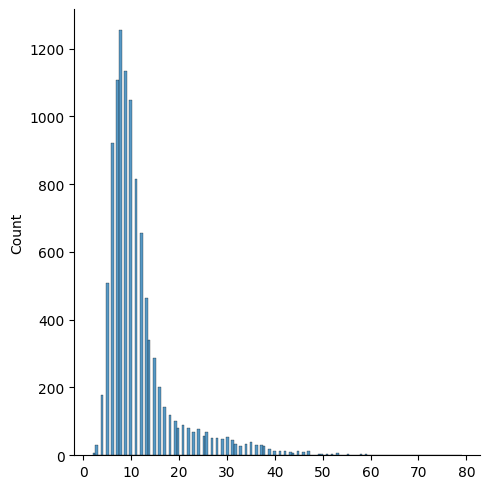

In [24]:
lengths = np.array([len(tokens) for tokens in train_tokens])
sns.displot(lengths)
plt.show()


In [25]:
MAX_LEN = 128

tokenized_train = torch.full((len(train_tokens), MAX_LEN), vocab["<pad>"], dtype=torch.long)
for i, tokens in enumerate(train_tokens):
    length = min(MAX_LEN, len(tokens))
    tokenized_train[i, :length] = torch.tensor(tokens[:length], dtype=torch.long)

tokenized_test = torch.full((len(test_tokens), MAX_LEN), vocab["<pad>"], dtype=torch.long)
for i, tokens in enumerate(test_tokens):
    length = min(MAX_LEN, len(tokens))
    tokenized_test[i, :length] = torch.tensor(tokens[:length], dtype=torch.long)


In [26]:
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [27]:
train_dataset = TensorDataset(
    tokenized_train,
    y_train_tensor,
)

test_dataset = TensorDataset(
    tokenized_test,
    y_test_tensor,
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# Custom transformer

In [28]:
import math

In [29]:
import math
from torch import nn

class PositionalEncoder(nn.Module):
    def __init__(self, max_length, embed_dim, dropout):
        super().__init__()
        self.pos_features = torch.zeros(max_length, embed_dim)

        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        freqs = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float) * \
                          (-math.log(10000) / embed_dim)).unsqueeze(0)

        arguments = positions * freqs
        self.pos_features[:, 0::2] = torch.sin(arguments)
        self.pos_features[:, 1::2] = torch.cos(arguments)
        self.pos_features = self.pos_features.unsqueeze(0)
        self.pos_features = nn.Parameter(self.pos_features, requires_grad=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        outputs = inputs + self.pos_features[:, :inputs.shape[1]]
        return self.dropout(outputs)

In [30]:
class Attention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout):
        super().__init__()
        self.attention_dim = emb_dim // num_heads

        self.KW = nn.Linear(emb_dim, self.attention_dim, bias=False)
        self.QW = nn.Linear(emb_dim, self.attention_dim, bias=False)
        self.VW = nn.Linear(emb_dim, self.attention_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        Q = self.QW(query)
        K = self.KW(key)
        V = self.VW(value)

        weight = Q @ K.transpose(1, 2) / math.sqrt(self.attention_dim)
        if mask is not None:
            weight = weight.masked_fill(mask, -math.inf)
        score = torch.softmax(weight, dim=-1)
        z = self.dropout(score) @ V

        return z, score



class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout):
        super().__init__()
        self.attention_heads = nn.ModuleList([Attention(emb_dim, num_heads, dropout)
                                              for _ in range(num_heads)])

        self.linear = nn.Linear(emb_dim, emb_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        attentions, attention_scores = [], []

        for head in self.attention_heads:
            attention, attention_score = head(query, key, value, mask)
            attentions += [attention]
            attention_scores += [attention_score]

        attentions = torch.cat(attentions, dim=-1)
        attention_scores = torch.stack(attention_scores, dim=-1)

        outputs = self.linear(attentions)
        outputs = self.dropout(outputs)

        return outputs, attention_scores

In [31]:
def create_padding_mask(tokens, pad_idx=vocab["<pad>"]):
    length = tokens.shape[-1]
    padding_mask = (tokens == pad_idx)
    padding_mask = padding_mask.unsqueeze(1).repeat(1, length, 1)

    return padding_mask


In [32]:
class TransformerLayer(nn.Module):
    def __init__(self, embed_dim, fc_dim, num_heads, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, inputs, mask):
        attention, score = self.self_attention(
            query=inputs,
            key=inputs,
            value=inputs,
            mask=mask,
        )
        outputs = inputs + attention
        outputs = self.norm1(outputs)
        outputs = outputs + self.feedforward(outputs)
        outputs = self.norm2(outputs)
        return outputs, score


class Transformer(nn.Module):
    def __init__(self, vocab_size, max_length, num_intent_classes,
                 embed_dim, fc_dim, num_heads, num_layers, dropout):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoder(max_length, embed_dim, dropout)
        self.layers = nn.ModuleList([
            TransformerLayer(embed_dim, fc_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(embed_dim, num_intent_classes)

    def forward(self, tokens):
        embeds = self.embedding(tokens) * math.sqrt(self.embed_dim)
        outputs = self.pos_encoder(embeds)

        padding_mask = create_padding_mask(tokens)
        attention_scores = []
        for layer in self.layers:
            outputs, attention_score = layer(outputs, padding_mask)
            attention_scores.append(attention_score)
        attention_scores = torch.stack(attention_scores, dim=-1)

        mask = (tokens != vocab["<pad>"]).to(torch.float).detach()
        lengths = mask.sum(dim=1).clamp_min(1).detach()
        outputs = (outputs * mask.unsqueeze(2)).sum(dim=1) / lengths.unsqueeze(1)

        logits = self.classifier(outputs)

        return logits, attention_scores


In [33]:
from IPython.display import clear_output

def plot_losses(train_losses, test_losses, train_f1_scores, test_f1_scores):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label="test")
    axs[0].set_ylabel("loss")

    axs[1].plot(range(1, len(train_f1_scores) + 1), train_f1_scores, label="train")
    axs[1].plot(range(1, len(test_f1_scores) + 1), test_f1_scores, label="test")
    axs[1].set_ylabel("f1_macro")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    plt.show()


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer(
    vocab_size=len(vocab),
    max_length=MAX_LEN,
    num_intent_classes=num_intent_classes,
    embed_dim=64,
    fc_dim=128,
    num_heads=4,
    num_layers=2,
    dropout=0.2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


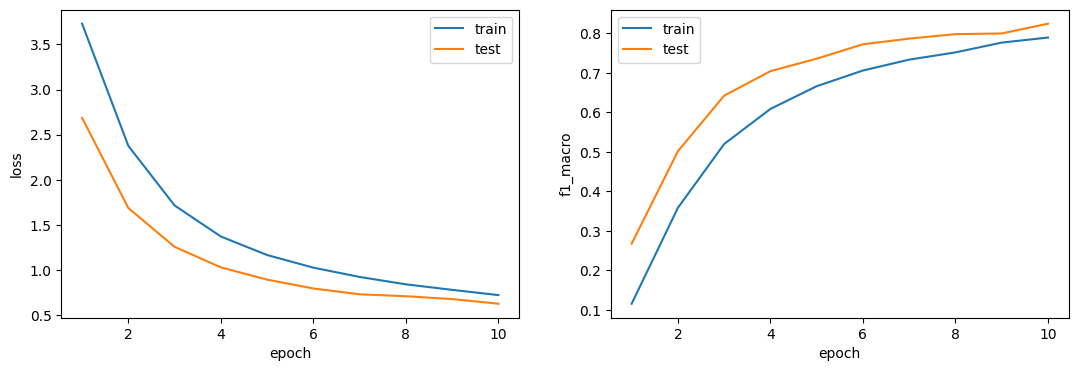

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.90      0.93      0.91        40
                                activate_my_card       0.95      0.88      0.91        40
                                       age_limit       0.80      0.93      0.86        30
                         apple_pay_or_google_pay       0.94      1.00      0.97        33
                                     atm_support       0.96      0.92      0.94        25
                                automatic_top_up       0.92      0.73      0.81        33
         balance_not_updated_after_bank_transfer       0.63      0.62      0.63        42
balance_not_updated_after_cheque_or_cash_deposit       0.75      0.95      0.84        44
                         beneficiary_not_allowed       0.82      0.79      0.81        39
                                 cancel_transfer       0.92      0.92      0.92        39
         

In [35]:
from tqdm.notebook import tqdm

num_epochs = 10

train_losses = []
test_losses = []

train_f1_scores = []
test_f1_scores = []

for epoch in range(1, num_epochs + 1):
    model.train()

    running_loss = 0.0

    train_true = []
    train_pred = []

    for tokens, intent_labels in tqdm(
        train_loader,
        desc=f"Training {epoch}/{num_epochs}",
    ):
        tokens = tokens.to(device)
        intent_labels = intent_labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(tokens)
        loss = criterion(logits, intent_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * tokens.size(0)

        preds = logits.argmax(dim=1)

        train_true.extend(intent_labels.cpu().numpy())
        train_pred.extend(preds.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)

    train_accuracy = accuracy_score(train_true, train_pred)
    train_f1 = f1_score(train_true, train_pred, average="macro", zero_division=0)

    model.eval()

    running_loss = 0.0

    test_true = []
    test_pred = []

    with torch.no_grad():
        for tokens, intent_labels in tqdm(
            test_loader,
            desc=f"Testing {epoch}/{num_epochs}",
        ):
            tokens = tokens.to(device)
            intent_labels = intent_labels.to(device)

            logits, _ = model(tokens)
            loss = criterion(logits, intent_labels)

            running_loss += loss.item() * tokens.size(0)

            preds = logits.argmax(dim=1)

            test_true.extend(intent_labels.cpu().numpy())
            test_pred.extend(preds.cpu().numpy())

    test_loss = running_loss / len(test_loader.dataset)

    test_accuracy = accuracy_score(test_true, test_pred)
    test_f1 = f1_score(test_true, test_pred, average="macro", zero_division=0)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
    print(f"Train accuracy: {train_accuracy:.4f}")
    print(f"Train f1_macro: {train_f1:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test f1_macro: {test_f1:.4f}")

plot_losses(train_losses, test_losses, train_f1_scores, test_f1_scores)

print(
    classification_report(
        test_true,
        test_pred,
        target_names=encoder_intent.classes_,
        zero_division=0,
    )
)


# BERT

In [36]:
!pip install -q transformers accelerate


In [37]:
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm


In [38]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [39]:
X_bert_train = X_train.astype(str)
X_bert_test = X_test.astype(str)


In [40]:
BERT_MAX_LEN = 128

train_encoding = tokenizer(
    list(X_bert_train),
    truncation=True,
    padding="max_length",
    max_length=BERT_MAX_LEN,
    return_tensors="pt",
)

test_encoding = tokenizer(
    list(X_bert_test),
    truncation=True,
    padding="max_length",
    max_length=BERT_MAX_LEN,
    return_tensors="pt",
)


In [41]:
y_train_tensor_bert = torch.tensor(y_train, dtype=torch.long)
y_test_tensor_bert = torch.tensor(y_test, dtype=torch.long)

train_dataset_bert = TensorDataset(
    train_encoding["input_ids"],
    train_encoding["attention_mask"],
    y_train_tensor_bert,
)

test_dataset_bert = TensorDataset(
    test_encoding["input_ids"],
    test_encoding["attention_mask"],
    y_test_tensor_bert,
)

BERT_BATCH_SIZE = 16

train_loader_bert = DataLoader(
    train_dataset_bert,
    batch_size=BERT_BATCH_SIZE,
    shuffle=True,
)

test_loader_bert = DataLoader(
    test_dataset_bert,
    batch_size=BERT_BATCH_SIZE,
    shuffle=False,
)


In [42]:
class BertIntentClassifier(nn.Module):
    def __init__(self, model_name, num_intent_classes, dropout=0.2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.intent_head = nn.Linear(hidden_size, num_intent_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        logits = self.intent_head(cls_embedding)

        return logits


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_bert = BertIntentClassifier(
    model_name=MODEL_NAME,
    num_intent_classes=num_intent_classes,
    dropout=0.2,
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_bert.parameters(),
    lr=2e-5,
    weight_decay=0.01,
)

num_epochs = 10
num_training_steps = num_epochs * len(train_loader_bert)
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
bert_train_losses = []
bert_test_losses = []

bert_train_f1_scores = []
bert_test_f1_scores = []

for epoch in range(1, num_epochs + 1):
    model_bert.train()

    running_loss = 0.0

    train_true = []
    train_pred = []

    for input_ids, attention_mask, intent_labels in tqdm(
        train_loader_bert,
        desc=f"BERT training {epoch}/{num_epochs}",
    ):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        intent_labels = intent_labels.to(device).long()

        optimizer.zero_grad()

        logits = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        loss = criterion(logits, intent_labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        preds = logits.argmax(dim=1)

        train_true.extend(intent_labels.detach().cpu().numpy())
        train_pred.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader_bert.dataset)

    train_accuracy = accuracy_score(train_true, train_pred)
    train_f1 = f1_score(train_true, train_pred, average="macro", zero_division=0)

    model_bert.eval()

    running_loss = 0.0

    test_true = []
    test_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, intent_labels in tqdm(
            test_loader_bert,
            desc=f"BERT testing {epoch}/{num_epochs}",
        ):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            intent_labels = intent_labels.to(device).long()

            logits = model_bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            loss = criterion(logits, intent_labels)

            running_loss += loss.item() * input_ids.size(0)

            preds = logits.argmax(dim=1)

            test_true.extend(intent_labels.detach().cpu().numpy())
            test_pred.extend(preds.detach().cpu().numpy())

    test_loss = running_loss / len(test_loader_bert.dataset)

    test_accuracy = accuracy_score(test_true, test_pred)
    test_f1 = f1_score(test_true, test_pred, average="macro", zero_division=0)

    bert_train_losses.append(train_loss)
    bert_test_losses.append(test_loss)

    bert_train_f1_scores.append(train_f1)
    bert_test_f1_scores.append(test_f1)

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
    print(f"Train accuracy: {train_accuracy:.4f}")
    print(f"Train f1_macro: {train_f1:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test f1_macro: {test_f1:.4f}")
    print(f"Learning rate: {scheduler.get_last_lr()[0]:.8f}")

print(
    classification_report(
        test_true,
        test_pred,
        target_names=encoder_intent.classes_,
        zero_division=0,
    )
)


BERT training 1/10:   0%|          | 0/654 [00:00<?, ?it/s]

BERT testing 1/10:   0%|          | 0/164 [00:00<?, ?it/s]


Epoch 1/10
Train loss: 3.2276 | Test loss: 1.2421
Train accuracy: 0.3279
Train f1_macro: 0.3425
Test accuracy: 0.7560
Test f1_macro: 0.7409
Learning rate: 0.00002000


BERT training 2/10:   0%|          | 0/654 [00:00<?, ?it/s]

BERT testing 2/10:   0%|          | 0/164 [00:00<?, ?it/s]

...

BERT testing 9/10:   0%|          | 0/164 [00:00<?, ?it/s]


Epoch 9/10
Train loss: 0.0333 | Test loss: 0.2927
Train accuracy: 0.9978
Train f1_macro: 0.9978
Test accuracy: 0.9228
Test f1_macro: 0.9249
Learning rate: 0.00000060


BERT training 10/10:   0%|          | 0/654 [00:00<?, ?it/s]

BERT testing 10/10:   0%|          | 0/164 [00:00<?, ?it/s]


Epoch 10/10
Train loss: 0.0303 | Test loss: 0.2926
Train accuracy: 0.9985
Train f1_macro: 0.9984
Test accuracy: 0.9224
Test f1_macro: 0.9245
Learning rate: 0.00000000
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.95      0.97        40
                                activate_my_card       1.00      0.93      0.96        40
                                       age_limit       1.00      1.00      1.00        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       1.00      0.88      0.94        25
                                automatic_top_up       0.96      0.82      0.89        33
         balance_not_updated_after_bank_transfer       0.80      0.88      0.84        42
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        44
                     

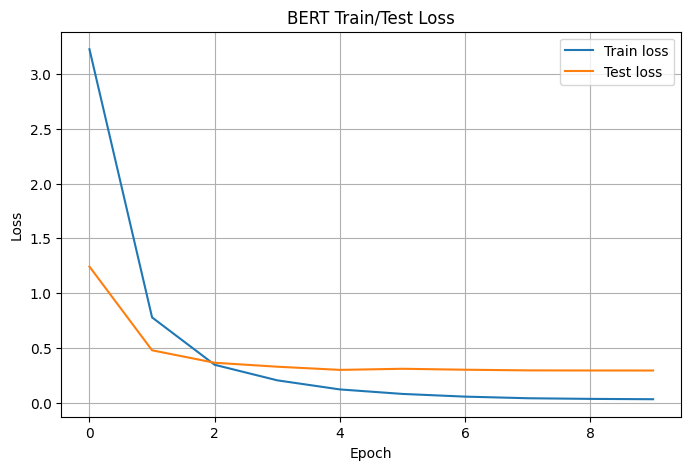

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(bert_train_losses, label="Train loss")
plt.plot(bert_test_losses, label="Test loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Train/Test Loss")
plt.legend()
plt.grid(True)

plt.show()


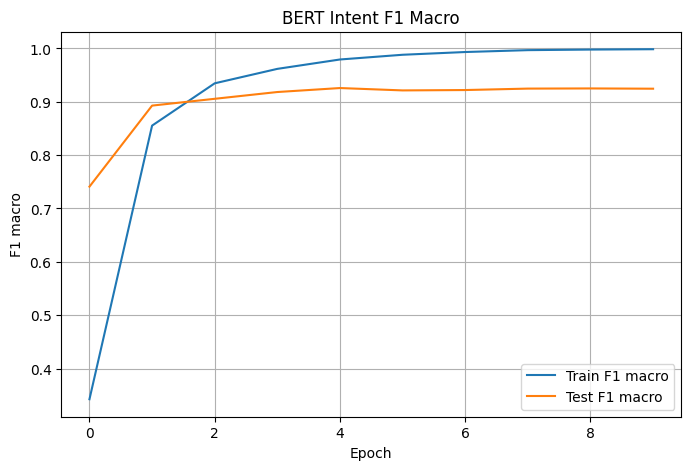

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(bert_train_f1_scores, label="Train F1 macro")
plt.plot(bert_test_f1_scores, label="Test F1 macro")

plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("BERT Intent F1 Macro")
plt.legend()
plt.grid(True)

plt.show()


In [47]:
def predict_intent_bert(text):
    model_bert.eval()

    encoding = tokenizer(
        [str(text)],
        truncation=True,
        padding="max_length",
        max_length=BERT_MAX_LEN,
        return_tensors="pt",
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        proba = torch.softmax(logits, dim=1)
        confidence, pred = torch.max(proba, dim=1)

    intent_label = encoder_intent.inverse_transform(pred.cpu().numpy())[0]

    return {
        "intent": intent_label,
        "confidence": float(confidence.cpu().item()),
    }


In [50]:
predict_intent_bert("loan payment failed")

{'intent': 'declined_card_payment', 'confidence': 0.17120681703090668}